In [1]:
# Cell 1: imports, paths, constants, and style

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
from scipy import stats

TASK_ROOT = Path.cwd().parent
INPUT = TASK_ROOT / "input"
OUTPUT = TASK_ROOT / "output"
FIGURES = OUTPUT / "figures"
RESULTS = OUTPUT / "results"
FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

EPS = 0.49
Y = 20
PAPER_BG = "#f3f0e9"
INK = "#263238"
EMP_COLOR = "#303030"
MODEL_ORDER = ["arw4", "unfitted_grw", "grw_y", "grw_global", "ar1_y", "ar1_s", "ar1_s_globalinit", "hurdle_ar1_s", "hurdle_ar1_s_p", "hurdle_ar3_s_p"]
MODEL_NAMES = {"arw4": "ARW4", "unfitted_grw": "Unfitted-GRW", "grw_y": "GRW-Y", "grw_global": "GRW-G", "ar1_y": "AR(1)-GRW-Y", "ar1_s": "AR(1)-GRW-S", "ar1_s_globalinit": "AR(1)-GRW-S-G", "hurdle_ar1_s": "Hurdle-AR(1)-GRW-S", "hurdle_ar1_s_p": "Hurdle-AR(1)-GRW-S-P", "hurdle_ar3_s_p": "Hurdle-AR(3)-GRW-S-P"}
MODEL_COLORS = {"arw4": "#0072B2", "unfitted_grw": "#D55E00", "grw_y": "#E69F00", "grw_global": "#8C564B", "ar1_y": "#009E73", "ar1_s": "#56B4E9", "ar1_s_globalinit": "#17BECF", "hurdle_ar1_s": "#CC79A7", "hurdle_ar1_s_p": "#6A3D9A", "hurdle_ar3_s_p": "#000000"}
STAGE_ORDER = ["0", "1-4", "5-7", "8-20"]
STAGE_SPANS = [("0", 0, 0), ("1-4", 1, 4), ("5-7", 5, 7), ("8-20", 8, 19)]
STAGE_BOUNDS = [0.5, 4.5, 7.5]


def resolve_root(name, marker):
    for candidate in [INPUT / name, INPUT]:
        if (candidate / marker).is_file():
            return candidate

def style_axis(ax, stages=False):
    ax.set_facecolor(PAPER_BG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(colors=INK)
    ax.xaxis.label.set_color(INK)
    ax.yaxis.label.set_color(INK)
    ax.title.set_color(INK)
    if stages:
        for boundary in STAGE_BOUNDS:
            ax.axvline(boundary, color="#9aa0a4", lw=0.8, ls=":", zorder=0)


def savefig(fig, filename):
    fig.savefig(FIGURES / filename, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())

mpl.rcParams.update({"figure.facecolor": PAPER_BG, "axes.facecolor": PAPER_BG, "savefig.facecolor": PAPER_BG, "font.size": 10, "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 8})
sns.set_theme(style="white", rc={"axes.facecolor": PAPER_BG, "figure.facecolor": PAPER_BG})
PREPARE = resolve_root("prepare", "df_traj_all.csv")
SIMULATE = resolve_root("simulate", "simulation-registry.csv")

In [2]:
emp = pd.read_csv(PREPARE / "df_traj_all.csv")
emp["CareerAge"] = emp["CareerAgeZero"].astype(int)
emp = emp.sort_values(["dblp_id", "CareerAge"]).copy()
grouped = emp.groupby("dblp_id", sort=False)
emp["pubs_adj_next_model"] = grouped["pubs_adj"].shift(-1)
emp["CareerAge_next_model"] = grouped["CareerAge"].shift(-1)
emp["log_pubs_adj"] = np.log(emp["pubs_adj"] + EPS)
emp["log_pubs_next"] = grouped["log_pubs_adj"].shift(-1)
emp["q_adj_delta"] = emp["pubs_adj_next_model"] - emp["pubs_adj"]
emp["log_delta"] = emp["log_pubs_next"] - emp["log_pubs_adj"]
emp["state"] = emp["pubs_adj"].gt(0).astype(int)
emp["next_state"] = emp["pubs_adj_next_model"].gt(0).astype(int)
is_next_year = emp["CareerAge_next_model"].eq(emp["CareerAge"] + 1)
emp_fit = emp.loc[is_next_year & emp["CareerAge"].between(0, Y - 1)].copy()

full_group = emp.groupby("dblp_id")["CareerAge"]
full_mask = full_group.transform("size").eq(Y + 1) & full_group.transform("min").eq(0) & full_group.transform("max").eq(Y)
emp_full_frame = emp.loc[full_mask].copy()
emp_panel_df = emp_full_frame.pivot(index="CareerAge", columns="dblp_id", values="pubs_adj").reindex(np.arange(Y + 1))
emp_panel = emp_panel_df.to_numpy(dtype=float)

simulation_registry = pd.read_csv(SIMULATE / "simulation-registry.csv")
available_models = [tag for tag in MODEL_ORDER if (SIMULATE / tag / "trajectories.npy").is_file()]
trajs = {tag: np.load(SIMULATE / tag / "trajectories.npy", mmap_mode="r", allow_pickle=False) for tag in available_models}

In [3]:
METRICS = [("mean_log_delta", "Mean log increment"), ("var_log_delta", "Variance of log increments"), ("mean_raw_delta", "Mean raw increment"), ("var_raw_delta", "Variance of raw increments")]

def empirical_summary():
    return emp_fit.groupby("CareerAge").agg(mean_log_delta=("log_delta", "mean"), var_log_delta=("log_delta", lambda x: x.var(ddof=0)), mean_raw_delta=("q_adj_delta", "mean"), var_raw_delta=("q_adj_delta", lambda x: x.var(ddof=0))).reindex(np.arange(Y)).reset_index().rename(columns={"CareerAge": "year"})

def simulated_summary(values):
    values = np.asarray(values, dtype=float)
    raw = values[1:] - values[:-1]
    log = np.log(values[1:] + EPS) - np.log(values[:-1] + EPS)
    return pd.DataFrame({"year": np.arange(Y), "mean_log_delta": log.mean(axis=1), "var_log_delta": log.var(axis=1), "mean_raw_delta": raw.mean(axis=1), "var_raw_delta": raw.var(axis=1)})

frames = [empirical_summary().assign(source="Empirical", model_tag="empirical")]
for tag in available_models:
    frames.append(simulated_summary(trajs[tag]).assign(source=MODEL_NAMES[tag], model_tag=tag))
delta_summary = pd.concat(frames, ignore_index=True)
delta_summary.to_csv(RESULTS / "delta-trajectory-summary.csv", index=False)
display(delta_summary.head())

,year,mean_log_delta,var_log_delta,mean_raw_delta,var_raw_delta,source,model_tag
0,0,0.279975,1.277029,1.338749,20.626017,Empirical,empirical
1,1,0.180069,1.043082,1.192032,24.926542,Empirical,empirical
2,2,0.071794,0.940583,0.518598,26.162875,Empirical,empirical
3,3,0.044680,0.935920,0.337892,29.111973,Empirical,empirical
4,4,-0.062821,0.927651,-0.439631,30.430004,Empirical,empirical


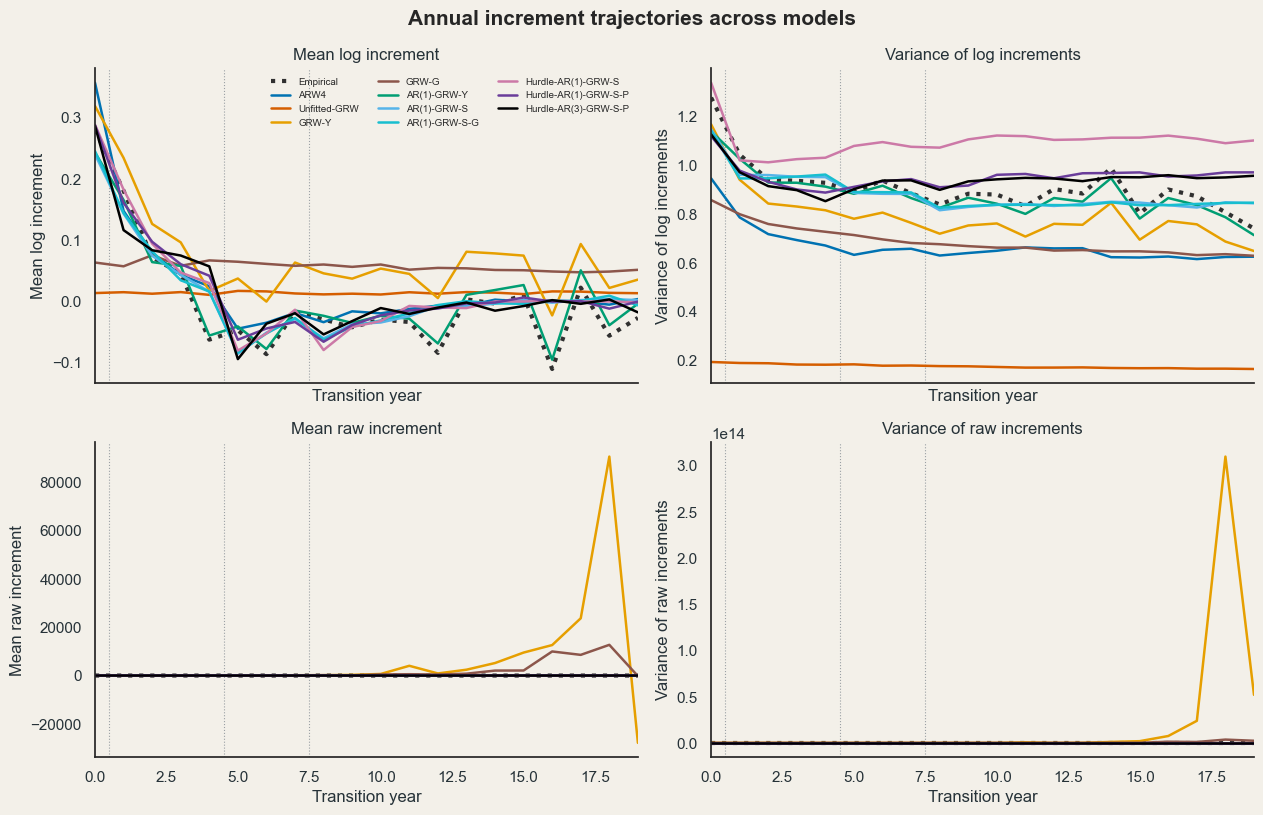

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12.8, 8.3), sharex=True)
fig.patch.set_facecolor(PAPER_BG)
for ax, (metric, title) in zip(axes.flat, METRICS):
    style_axis(ax, stages=True)
    empirical = delta_summary.loc[delta_summary["model_tag"].eq("empirical")]
    ax.plot(empirical["year"], empirical[metric], color=EMP_COLOR, lw=3, ls=":", label="Empirical")
    for tag in available_models:
        frame = delta_summary.loc[delta_summary["model_tag"].eq(tag)]
        ax.plot(frame["year"], frame[metric], color=MODEL_COLORS[tag], lw=1.8, label=MODEL_NAMES[tag])
    ax.set(xlim=(0, Y - 1), xlabel="Transition year", ylabel=title, title=title)
axes[0, 0].legend(frameon=False, ncol=3, fontsize=7)
fig.suptitle("Annual increment trajectories across models", fontsize=15, fontweight="bold")
fig.tight_layout()
savefig(fig, "delta_trajectories_all_metrics.png")
plt.show()

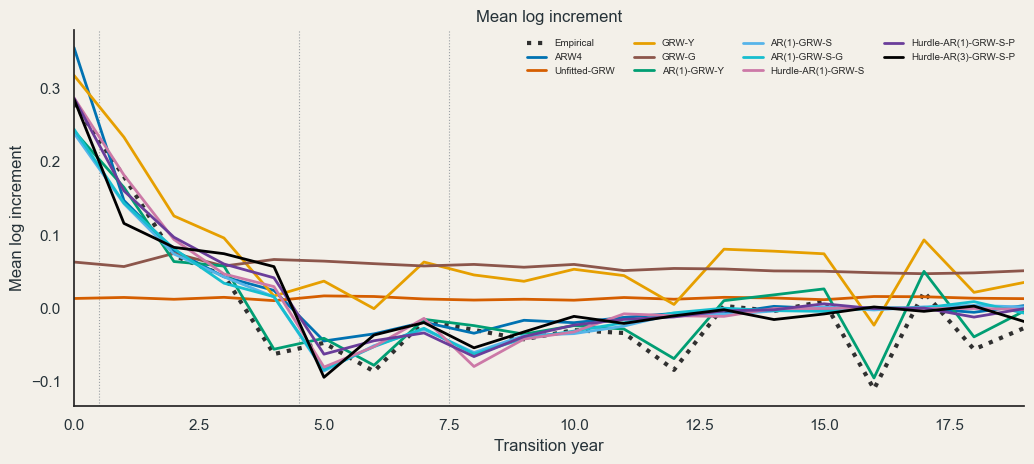

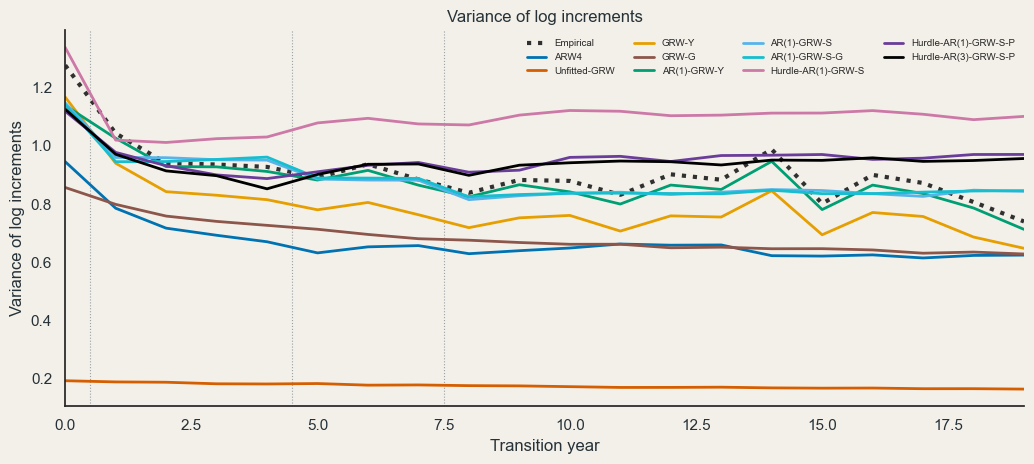

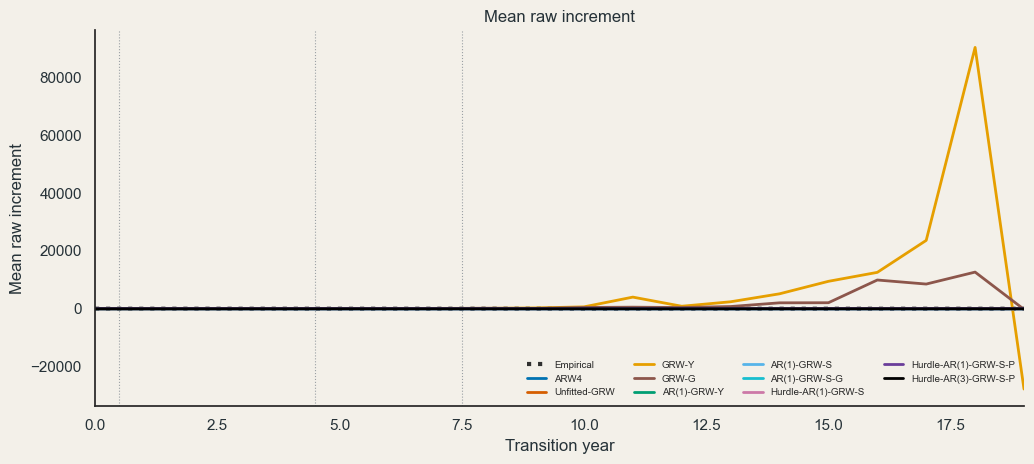

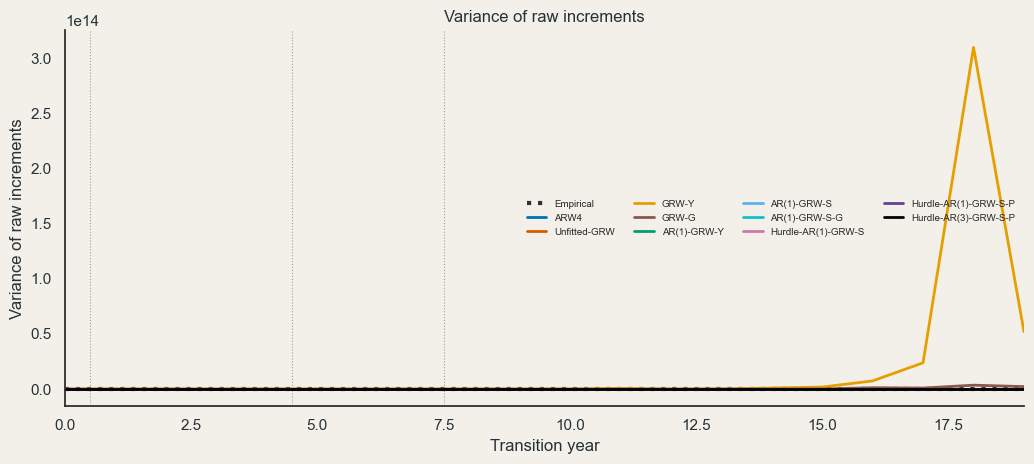

In [5]:
for metric, title in METRICS:
    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    fig.patch.set_facecolor(PAPER_BG)
    style_axis(ax, stages=True)
    empirical = delta_summary.loc[delta_summary["model_tag"].eq("empirical")]
    ax.plot(empirical["year"], empirical[metric], color=EMP_COLOR, lw=3, ls=":", label="Empirical")
    for tag in available_models:
        frame = delta_summary.loc[delta_summary["model_tag"].eq(tag)]
        ax.plot(frame["year"], frame[metric], color=MODEL_COLORS[tag], lw=2, label=MODEL_NAMES[tag])
    ax.set(xlim=(0, Y - 1), xlabel="Transition year", ylabel=title, title=title)
    ax.legend(frameon=False, ncol=4, fontsize=7)
    fig.tight_layout()
    savefig(fig, f"delta_trajectory_{metric}.png")
    plt.show()